In [1]:
import numpy as np
import pandas as pd
import skimage
import matplotlib.pyplot as plt
import seaborn as sb

In [2]:
df = pd.read_csv('/scr/yren/all_data_micronuclei_no_rescale/metadata.csv')
subset = df[df.datasets == 'mnfinder_validation']
subset.filenames.to_list()[0]

'2022-05-26_RPE1-2198.phenotype.tif'

In [3]:
df.datasets.unique()

array(['HeLa', 'RPE1', 'pilot', 'screen', 'mnfinder_train',
       'mnfinder_test', 'mnfinder_validation', 'BBBC039'], dtype=object)

In [138]:
df[(df.datasets == 'BBBC039') & (df.split == 'validation')].filenames.to_list()[10]

'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1.phenotype.tif'

- screen

In [135]:
path = '/scr/yren/all_data_micronuclei_no_rescale/validation/'
screen_path = path + 'C2-20X_c0-DAPI-GFP_A2_Tile-5.phenotype.tif'
dinomn_path = '/scr/yren/dinomn_figures/figure4/dinomn_predictions/C2-20X_c0-DAPI-GFP_A2_Tile-5._probabilities.npy'

input_screen = skimage.io.imread(screen_path)
gt_screen = skimage.io.imread(screen_path.replace('phenotype.tif','phenotype_outlines.png'))
nuclei_gt_screen = skimage.io.imread(screen_path.replace('phenotype.tif','nuclei-clean.tif'))
dinomn_screen = np.load(dinomn_path)
mnfinder_screen = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_screen = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_screen = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

- BBBC039

In [139]:
imid = 'IXMtest_F22_s6_w1F4C7ADE4-B68D-4D30-A063-722B87AA2DA1'
bbbc039_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_bbbc039 = skimage.io.imread(bbbc039_path)
gt_bbbc039 = skimage.io.imread(bbbc039_path.replace('phenotype.tif','phenotype_outlines.png'))
nuclei_gt_bbbc039 = skimage.io.imread(bbbc039_path.replace('phenotype.tif','nuclei-clean.tif'))
dinomn_bbbc039 = np.load(dinomn_path)
mnfinder_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_bbbc039 = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

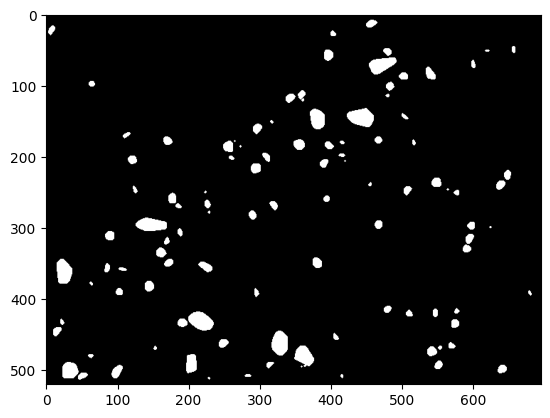

In [156]:
plt.imshow(mnfinder_bbbc039 > 0, cmap='gray')

- HeLa & RPE1

In [140]:
imid = 'C1-20X_c0_B3_Tile-24'
hela_rpe1_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_hela_rpe1 = skimage.io.imread(hela_rpe1_path)
gt_hela_rpe1 = skimage.io.imread(hela_rpe1_path.replace('phenotype.tif','phenotype_outlines.png'))
nuclei_gt_hela_rpe1 = skimage.io.imread(hela_rpe1_path.replace('phenotype.tif','nuclei-clean.tif'))
dinomn_hela_rpe1 = np.load(dinomn_path)
mnfinder_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_hela_rpe1 = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

- MNFinder Data

In [141]:
imid = '2022-05-26_RPE1-2198'
mnfinder_path = path + f'{imid}.phenotype.tif'
dinomn_path = f'/scr/yren/dinomn_figures/figure4/dinomn_predictions/{imid}._probabilities.npy'

input_mnfinder = skimage.io.imread(mnfinder_path)
gt_mnfinder = skimage.io.imread(mnfinder_path.replace('phenotype.tif','phenotype_outlines.png'))
nuclei_gt_mnfinder = skimage.io.imread(mnfinder_path.replace('phenotype.tif','nuclei-clean.tif'))
dinomn_mnfinder = np.load(dinomn_path)
mnfinder_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'mnfinder_predictions'))
cellpose_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'cellpose_predictions'))
microsam_mnfinder = np.load(dinomn_path.replace('dinomn_predictions', 'microSAM_predictions'))

# Grid Plot

# Add the nuclei mask first, remember to be gray not white

In [142]:
inputs = [input_screen, input_bbbc039, input_hela_rpe1, input_mnfinder]
gt = [gt_screen, gt_bbbc039, gt_hela_rpe1, gt_mnfinder]
gt_nuclei = [nuclei_gt_screen, nuclei_gt_bbbc039, nuclei_gt_hela_rpe1, nuclei_gt_mnfinder]
dinomn = [dinomn_screen, dinomn_bbbc039, dinomn_hela_rpe1, dinomn_mnfinder]
mnfinder = [mnfinder_screen, mnfinder_bbbc039, mnfinder_hela_rpe1, mnfinder_mnfinder]
cellpose = [cellpose_screen, cellpose_bbbc039, cellpose_hela_rpe1, cellpose_mnfinder]
microsam = [microsam_screen, microsam_bbbc039, microsam_hela_rpe1, microsam_mnfinder]

In [143]:
dinomn_2 = []
for i in range(len(gt_nuclei)):
    H, W = dinomn[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (dinomn[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]

    # Step 2: add overlap (yellow)
    im[overlap] = [255, 255, 0]

    # Step 3: prediction only (red)
    im[pred_only] = [255, 0, 0]

    # Step 4: ground truth only (green)
    im[gt_only] = [0, 255, 0]

    dinomn_2.append(im)


In [144]:
gray_mask = (gt_nuclei[0] > 0)
print(gray_mask.shape)

(2960, 2960)


In [145]:
gt_2 = []
for i in range(len(gt_nuclei)):
    H,W = gt_nuclei[i].shape
    im = np.zeros((H,W,3))
    
    im[:,:,:] = im[:,:,:] + (gt_nuclei[i][..., np.newaxis] > 0) * 0.5
    
    im[:,:,1] = (gt[i] > 0) * 1
    
    gt_2.append(im)

In [146]:
gt_2 = []
for i in range(len(gt_nuclei)):
    H, W = gt[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    gt_mask     = (gt[i] > 0)

    im[nuclei_mask] = [128, 128, 128]
    im[gt_mask] = [0, 255, 0]

    gt_2.append(im)


In [147]:
mnfinder_2 = []
for i in range(len(gt_nuclei)):
    H, W = mnfinder[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (mnfinder[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]

    # Step 2: add overlap (yellow)
    im[overlap] = [255, 255, 0]

    # Step 3: prediction only (red)
    im[pred_only] = [255, 0, 0]

    # Step 4: ground truth only (green)
    im[gt_only] = [0, 255, 0]

    mnfinder_2.append(im)


In [148]:
cellpose_2 = []
for i in range(len(gt_nuclei)):
    H, W = cellpose[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (cellpose[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]

    # Step 2: add overlap (yellow)
    im[overlap] = [255, 255, 0]

    # Step 3: prediction only (red)
    im[pred_only] = [255, 0, 0]

    # Step 4: ground truth only (green)
    im[gt_only] = [0, 255, 0]

    cellpose_2.append(im)


In [149]:
microsam_2 = []
for i in range(len(gt_nuclei)):
    H, W = microsam[i].shape
    im = np.zeros((H, W, 3), dtype=np.uint8)

    # Compute binary masks
    nuclei_mask = (gt_nuclei[i] > 0)
    pred_mask   = (microsam[i] > 0)
    gt_mask     = (gt[i] > 0)

    overlap = pred_mask & gt_mask # correct prediction
    pred_only = pred_mask & ~gt_mask # false positive
    gt_only = gt_mask & ~pred_mask # false negative

    # Step 1: draw nuclei first (gray)
    im[nuclei_mask] = [128, 128, 128]

    # Step 2: add overlap (yellow)
    im[overlap] = [255, 255, 0]

    # Step 3: prediction only (red)
    im[pred_only] = [255, 0, 0]

    # Step 4: ground truth only (green)
    im[gt_only] = [0, 255, 0]

    microsam_2.append(im)


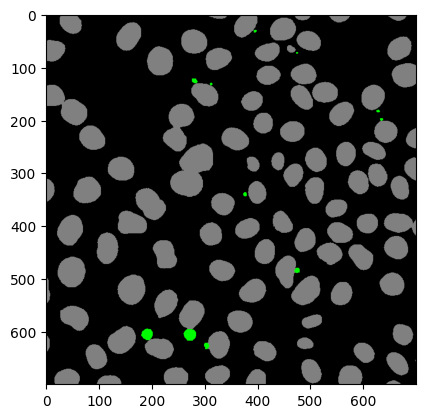

In [150]:
plt.imshow(gt_2[0][2100:2100+700, 1300:1300+700, :], cmap='gray')

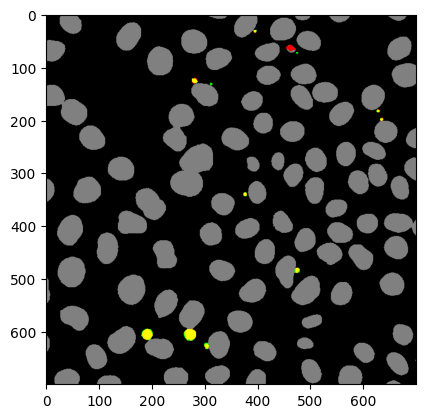

In [151]:
plt.imshow(dinomn_2[0][2100:2100+700, 1300:1300+700,:] )

In [152]:
collections = [inputs, gt_2, dinomn_2, mnfinder_2, cellpose_2, microsam_2]

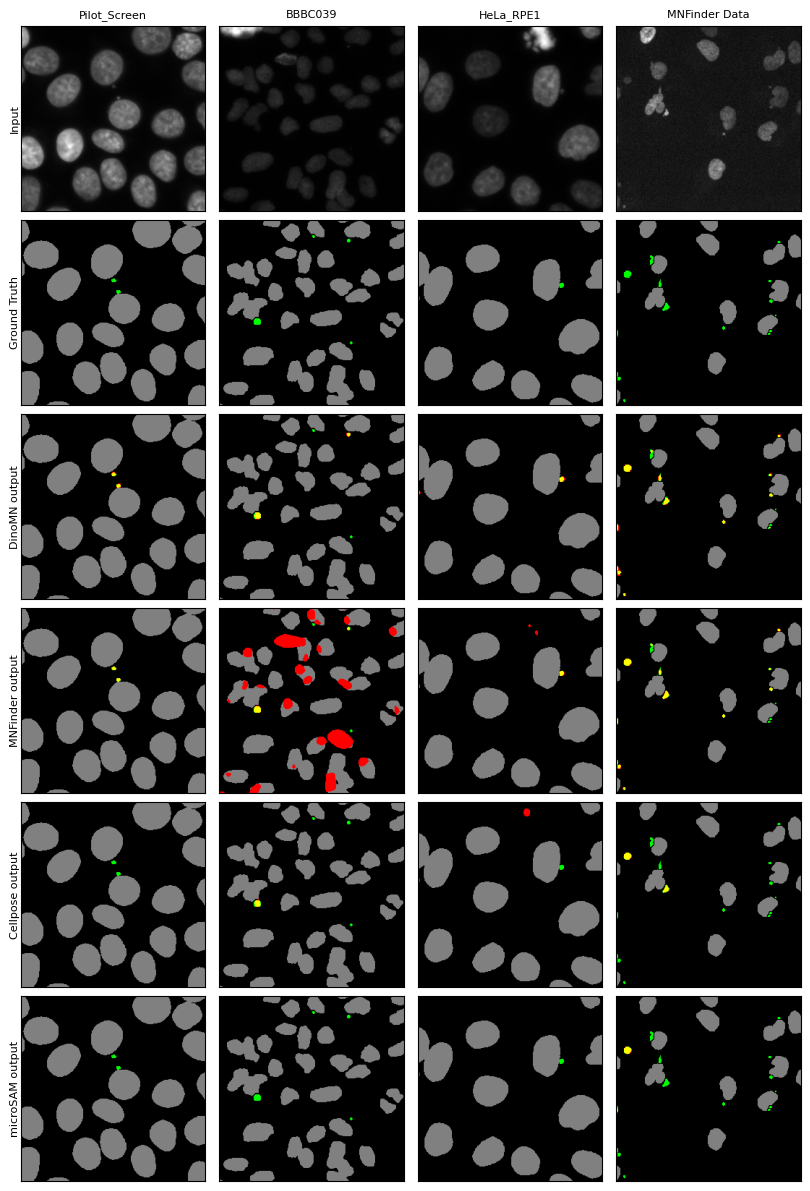

In [160]:
fig, ax = plt.subplots(6,4, figsize=(15,15))
plt.subplots_adjust(wspace=-0.65, hspace=0.05)


# Labels for columns and rows
col_labels = ['Pilot_Screen', 'BBBC039', 'HeLa_RPE1', 'MNFinder Data']
row_labels = ['Input', 'Ground Truth', 'DinoMN output', 'MNFinder output', 'Cellpose output', 'microSAM output']

for i in range(6):
    for j in range(4):
        if j==0: # Pilot Screen
            r,c = 2200,1800
        elif j == 1: # BBBC039
            r,c = 250,50
        elif j==2: # HeLa RPE1
            r,c = 1700,2000
        elif j==3: # MNFinder
            r,c = 150,300
        if i == 0:
            PS=256
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS], cmap='gray')
        else:
            PS=256
            ax[i,j].imshow(collections[i][j][r:r+PS,c:c+PS,:])

        # Hide ticks but keep labels
        ax[i, j].tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

        if i == 0:
            ax[i, j].set_title(col_labels[j], fontsize=8)

        # Set row labels on the left side
        if j == 0:
            # ax[i, j].set_ylabel(row_labels[i], fontsize=10, rotation=0, labelpad=30, va='center')
            ax[i, j].set_ylabel(row_labels[i], fontsize=8, rotation=90, va='center')


# plt.tight_layout()
plt.show()